In [10]:
import pandas as pd
import numpy as np
import itertools
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load Data

In [31]:
X_train = pd.read_csv('property_data_train_x_engineered.csv').drop(columns=['ListPrice', 'OriginalListPrice', 'ListingKey'])
X_test = pd.read_csv('property_data_test_x_engineered.csv').drop(columns=['ListPrice', 'OriginalListPrice', 'ListingKey'])

y_train = pd.read_csv('property_data_train_y_engineered.csv')
y_test = pd.read_csv('property_data_test_y_engineered.csv')

# XGBoost Model

Create hyperparameter grid

In [32]:
hyperparams = {
    "max_depth": [6, 10, 14],
    "learning_rate": [.1, .01, .001],
    "n_estimators": [100, 500, 1000]
}

Define XGBoost testing function

In [33]:
def train_test_xgboost(params, X_train, X_test, y_train, y_test):
  xgb_reg = xgb.XGBRegressor(
      objective='reg:squarederror',
      max_depth=params[0],
      learning_rate=params[1],
      n_estimators=params[2],
      early_stopping_rounds=50,
      random_state=42
  )
  xgb_reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
  y_pred = xgb_reg.predict(X_test)
  return np.sqrt(mean_squared_error(y_test, y_pred)), r2_score(y_test, y_pred), xgb_reg

In [34]:
best_score = np.inf
best_params = []
best_model = 0
best_r2 = 0

for params in itertools.product(*hyperparams.values()):
  rmse, r2, model = train_test_xgboost(params, X_train, X_test, y_train, y_test)
  print(f"HYPERPARAMS:\nDEPTH: {params[0]}\nLR: {params[1]}\nESTIMATORS: {params[2]}\nRMSE: {rmse}\nR2: {r2}\n{"=" * 25}")
  if rmse < best_score:
    best_score = rmse
    best_params = params
    best_model = model
    best_r2 = r2

print(f"BEST HYPERPARAMS:\nDEPTH: {best_params[0]}\nLR: {best_params[1]}\nESTIMATORS: {best_params[2]}\nBEST RMSE: {best_score}\nBEST R2: {best_r2}")

HYPERPARAMS:
DEPTH: 6
LR: 0.1
ESTIMATORS: 100
RMSE: 326749.79217743967
R2: 0.8754233121871948
HYPERPARAMS:
DEPTH: 6
LR: 0.1
ESTIMATORS: 500
RMSE: 318465.28617103625
R2: 0.8816603422164917
HYPERPARAMS:
DEPTH: 6
LR: 0.1
ESTIMATORS: 1000
RMSE: 318465.28617103625
R2: 0.8816603422164917
HYPERPARAMS:
DEPTH: 6
LR: 0.01
ESTIMATORS: 100
RMSE: 481827.4673448993
R2: 0.7291123867034912
HYPERPARAMS:
DEPTH: 6
LR: 0.01
ESTIMATORS: 500
RMSE: 337102.6843203714
R2: 0.8674039840698242
HYPERPARAMS:
DEPTH: 6
LR: 0.01
ESTIMATORS: 1000
RMSE: 328431.45086912735
R2: 0.8741377592086792
HYPERPARAMS:
DEPTH: 6
LR: 0.001
ESTIMATORS: 100
RMSE: 855179.1407746099
R2: 0.1466636061668396
HYPERPARAMS:
DEPTH: 6
LR: 0.001
ESTIMATORS: 500
RMSE: 636556.2902493385
R2: 0.527197539806366
HYPERPARAMS:
DEPTH: 6
LR: 0.001
ESTIMATORS: 1000
RMSE: 482695.0092304663
R2: 0.7281360030174255
HYPERPARAMS:
DEPTH: 10
LR: 0.1
ESTIMATORS: 100
RMSE: 319282.4082094095
R2: 0.8810523152351379
HYPERPARAMS:
DEPTH: 10
LR: 0.1
ESTIMATORS: 500
RMSE: 3

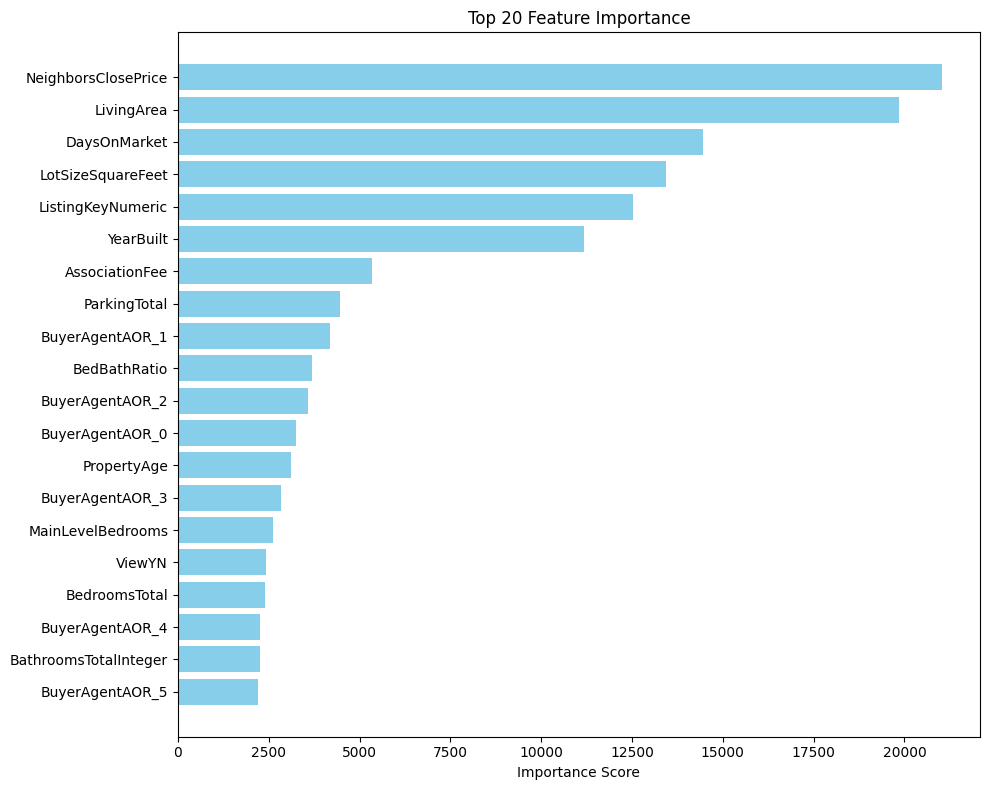

In [35]:
importance = best_model.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()